In [1]:
import pandas as pd
import os

filename = 'df_stage2_biso.pkl'
df_stage2 = pd.read_pickle(filename)
df_stage2[:3]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.010,0.007028,0.003513,3.141510e-07,0.010
1,100.020,0.007028,0.003513,6.283020e-07,0.020
2,100.035,0.007028,0.003513,1.099528e-06,0.035


In [ ]:
len(df_stage2)

15000

In [4]:
import numpy as np


d_eps = df_stage2[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)

step_length = np.sqrt(d_eps['Eps_1']**2 + d_eps['Eps_2']**2 + d_eps['Eps_3']**2)

df_stage2['s'] = step_length.cumsum()


### 1. Численное дифференцирование методом сглаживающих сплайнов

Для обработки экспериментальных данных используется метод **сглаживающих сплайнов степени k** (Smoothing Cubic Splines). Мы ищем функцию $g(t)$, которая минимизирует функционал:

$$ p \sum_{i} w_i (y_i - g(t_i))^2 + (1-p) \int (g''(t))^2 dt $$

Где параметр сглаживания $s$ (связанный с $p$) определяет баланс между точностью приближения к исходным точкам и гладкостью кривой.

**Алгоритм подбора гиперпараметров $(s, k)$:**

Для выбора оптимальной степени полинома $k$ и параметра сглаживания $s$ применяется метод **поиска на сетке (Grid Search)** с валидацией по эталонному аналитическому решению.

Калибровка производится на компоненте $\ni_3$ (сдвиговая деформация), так как для неё физика процесса в ANSYS (сжимаемый материал) совпадает с аналитической кинематической моделью (нет влияния изменения объема).

Минимизируется взвешенная функция потерь, учитывающая точность первой, второй и третьей производных:

$$ Score(s, k) = w_1 \cdot \text{MSE}(\dot{\ni}_3^{num}, \dot{\ni}_3^{ana}) + w_2 \cdot \text{MSE}(\ddot{\ni}_3^{num}, \ddot{\ni}_3^{ana}) + w_3 \cdot \text{MSE}(\dddot{\ni}_3^{num}, \dddot{\ni}_3^{ana}) $$

где:
*   $\text{MSE}$ — нормированная среднеквадратичная ошибка;
*   $w_i$ — весовые коэффициенты (выбираются $w_3 \gg w_1$, чтобы обеспечить гладкость старших производных).

Параметры $(s, k)$, обеспечивающие минимум ошибки для $\ni_3$, затем применяются для дифференцирования остальных компонент вектора ($\ni_1, \ni_2$).

In [ ]:
import numpy as np
from core.derivatives.spline import find_optimal_spline_params_mse
from core.derivatives.analytical import AnalyticalDerivatives


a_path = r"a.txt"
with open(a_path, "r") as f:
        a = float(f.read().strip())

c_path = r"c.txt"
with open(c_path, "r") as f:
        c = float(f.read().strip())

analytical = AnalyticalDerivatives(c=c, a=a) 


s_grid = np.logspace(-15, -1, 100) # От 1e-15 до 1e-1
k_grid = [3, 4, 5]           

best_s, best_k, res_df = find_optimal_spline_params_mse(
    df_stage2, 
    col_name="Eps_3", 
    time_col="s",
    analytic_obj=analytical,
    comp_idx=2,
    s_range=s_grid,
    k_range=k_grid
)

(best_s, best_k)

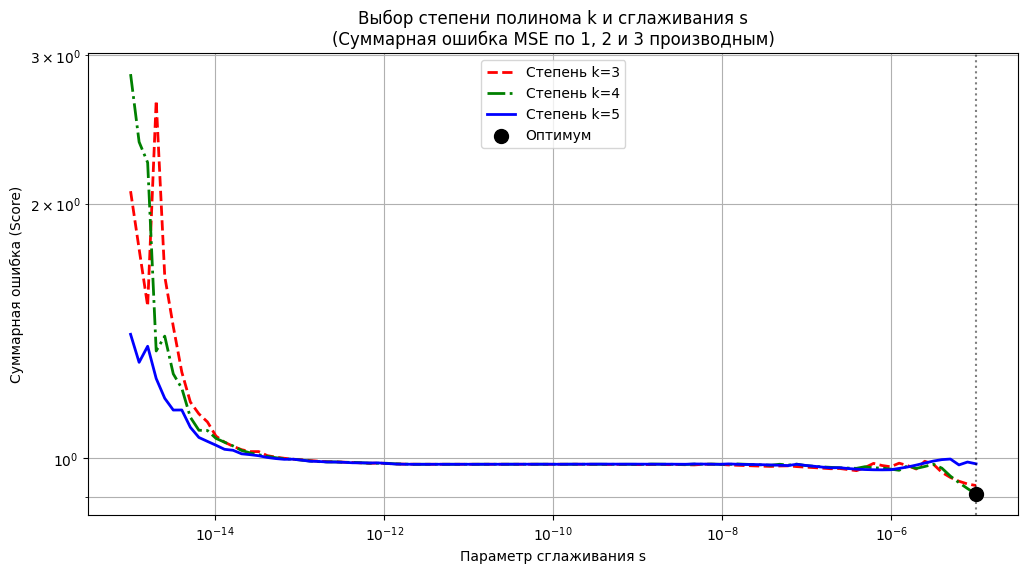

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

colors = {3: "red", 4: "green", 5: "blue"}
styles = {3: "--", 4: "-.", 5: "-"}

for k in k_grid:
    subset = res_df[res_df["k"] == k]
    plt.loglog(subset["s"], subset["score"], 
               color=colors[k], linestyle=styles[k], linewidth=2, 
               label=f"Степень k={k}")

# Отмечаем оптимум
plt.axvline(best_s, color="k", linestyle=":", alpha=0.5)
plt.scatter([best_s], [res_df["score"].min()], color="black", s=100, zorder=5, label="Оптимум")

plt.title("Выбор степени полинома k и сглаживания s\n(Суммарная ошибка MSE по 1, 2 и 3 производным)")
plt.xlabel("Параметр сглаживания s")
plt.ylabel("Суммарная ошибка (Score)")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

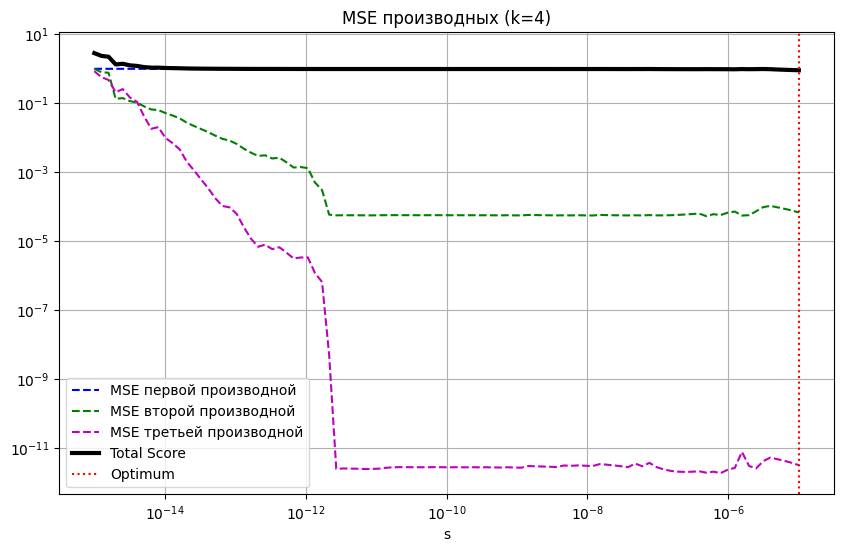

In [8]:
plt.figure(figsize=(10, 6))
subset = res_df[res_df['k'] == best_k]

plt.loglog(subset['s'], subset['mse1_norm'], 'b--', label='MSE первой производной')
plt.loglog(subset['s'], subset['mse2_norm'], 'g--', label='MSE второй производной')
plt.loglog(subset['s'], subset['mse3_norm'], 'm--', label='MSE третьей производной')
plt.loglog(subset['s'], subset['score'], 'k-', lw=3, label='Total Score')

plt.axvline(best_s, color='r', linestyle=':', label='Optimum')
plt.title(f'MSE производных (k={best_k})')
plt.xlabel('s')
plt.legend()
plt.grid(True)
plt.show()

### 2. Адаптивный подбор параметров сглаживания (Unsupervised Tuning)

При обработке реальных экспериментальных данных аналитическое решение ("Ground Truth") неизвестно. Следовательно, мы не можем вычислять ошибку производных напрямую.

В этом случае применяется эвристический подход к регуляризации. Задача сводится к поиску баланса между двумя конфликтующими целями:
1.  **Точность аппроксимации (Fidelity):** Сплайн должен проходить максимально близко к исходным точкам эксперимента.
2.  **Гладкость кривой (Regularity):** Производные сплайна (особенно высшие, используемые для расчета кручения) не должны содержать нефизичных осцилляций ("шума").

**Целевой функционал:**
Мы минимизируем комбинированную функцию потерь $J(s, k)$ на сетке параметров:

$$ J(s, k) = w_{fit} \cdot \overline{\text{MSE}}(y, S) + w_{smooth} \cdot \overline{\text{Roughness}}(\dddot{S}) $$

где:
*   $S(t)$ — построенный сплайн.
*   $\overline{\text{MSE}}(y, S)$ — нормированная среднеквадратичная ошибка отклонения сплайна от исходных точек.
*   $\overline{\text{Roughness}}(\dddot{S})$ — нормированная метрика "шероховатости" (Total Variation) третьей производной (рывка):
    $$ \text{Roughness} = \sum_{i} | \dddot{S}_{i+1} - \dddot{S}_i | $$

**Интерпретация:**
*   При малых $s$ ошибка аппроксимации минимальна, но "шероховатость" производных огромна (сплайн описывает шум).
*   При больших $s$ производные гладкие, но растет ошибка аппроксимации (сплайн "уходит" от экспериментальных точек).
*   Оптимум находится в точке минимума функционала $J$, что соответствует перегибу на L-кривой (L-curve criterion).

In [ ]:
from core.derivatives.spline import find_optimal_spline_params_rough


s_grid = np.logspace(-15, -1, 100) # От 1e-15 до 1e-1
k_grid = [3, 4, 5]  
# weights_exp = (1.0, 0.0, 0.0, 0.5) 

best_s, best_k, res_exp_df = find_optimal_spline_params_rough(
    df_stage2, 
    col_name='Eps_3', 
    time_col='s',
    s_range=s_grid,
    k_range=k_grid,
    # weights=weights_exp
)

(best_s, best_k)

In [ ]:
plt.figure(figsize=(12, 6))

colors = {3: "red", 4: "green", 5: "blue"}
styles = {3: "--", 4: "-", 5: "-."}

for k in k_grid:
    subset = res_exp_df[res_exp_df["k"] == k]
    plt.loglog(subset["s"], subset["score"], 
               color=colors[k], linestyle=styles[k], linewidth=2, 
               label=f"Степень k={k}")

# Отмечаем оптимум
plt.axvline(best_s, color="k", linestyle=":", alpha=0.5)
plt.scatter([best_s], [res_exp_df["score"].min()], color="black", s=100, zorder=5, label="Оптимум")

plt.title("Выбор степени полинома k и сглаживания s")
plt.xlabel("Параметр сглаживания s")
plt.ylabel("Суммарная ошибка (Score)")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
subset = res_exp_df[res_exp_df['k'] == best_k]

plt.loglog(subset['s'], subset['mse_func_norm'], 'b--', label='Ошибка аппроксимации (MSE)')
plt.loglog(subset['s'], subset['rough_d3_norm'], 'g--', label='Пилообразность производной (Roughness D3)')
plt.loglog(subset['s'], subset['score'], 'k-', lw=3, label='Total Score')

plt.axvline(best_s, color='r', linestyle=':', label='Optimum')
plt.title(f'Баланс точности и гладкости (k={best_k})')
plt.xlabel('s')
plt.legend()
plt.grid(True)
plt.show()